# CloudDrift — SHAP Analysis (Track 2 Explainability)

This notebook implements the second of CloudDrift's two explainability tracks:

| Track | Location | Method | Speed |
|-------|----------|--------|-------|
| 1 | Production API (`/detect`) | Z-score deviation ranking | Microseconds |
| 2 | This notebook | SHAP TreeExplainer on Isolation Forest | Seconds per row |

Track 1 is fast enough to run on every live request. Track 2 is the rigorous,
mathematically exact explanation (Shapley values from cooperative game theory)
used here for deep analysis and to validate that Track 1's lightweight
heuristic is trustworthy.

**Scope:** SHAP explains the Isolation Forest only. The TCN Autoencoder is a
neural network and would require a different explainer (DeepExplainer /
GradientExplainer) — out of scope for this capstone.

**On the environment:** `shap` was initially blocked on this project's Python
3.13 environment by a `numba`/`llvmlite` resolution issue (see `ADR-001`).
That was resolved by pinning explicit `numba`/`llvmlite` floor versions as
direct dependencies — this notebook runs in the same environment as the
rest of the project, no special setup required.

In [1]:
import copy
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Make src/ importable for the Day 6 ensemble code and Track 1 comparison
sys.path.insert(0, "..")

from src.models.ensemble import (
    compute_ensemble_score, compute_if_scores, compute_tcn_scores,
    load_ensemble_metadata, normalize_scores, rank_top_anomalies,
)
from src.models.isolation_forest import load_isolation_forest
from src.models.tcn_autoencoder import load_tcn_autoencoder
from src.utils.explanation import compute_feature_deviation_scores, load_reference_stats

plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path("..").resolve()
import os
os.chdir(PROJECT_ROOT)  # shift kernel cwd to project root so module default paths resolve correctly.resolve()
import os
os.chdir(PROJECT_ROOT)  # shift kernel cwd to project root so module default paths resolve correctly
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = ARTIFACTS_DIR / "shap_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"shap version: {shap.__version__}")
print(f"Plots will be saved to: {PLOTS_DIR.resolve()}")

shap version: 0.52.0
Plots will be saved to: /home/lobora/projects/clouddrift/artifacts/shap_plots


In [2]:
# Load the Isolation Forest model and feature metadata
if_model = load_isolation_forest()
print(f"Loaded Isolation Forest: {if_model.n_estimators} estimators")

with open(ARTIFACTS_DIR / "feature_metadata.json") as f:
    feature_cols = json.load(f)["nab_feature_cols"]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

val_df = pd.read_parquet(PROCESSED_DIR / "nab_val_features.parquet")
print(f"Validation set: {val_df.shape[0]:,} rows")

# Recompute the Day 6 ensemble scores and rank the top 5 anomaly windows
# directly here — no intermediate hand-off file needed since this notebook
# runs in the same environment as the rest of the project.
tcn_model = load_tcn_autoencoder()
ensemble_meta = load_ensemble_metadata()

if_scores  = compute_if_scores(if_model, val_df, feature_cols)
tcn_scores = compute_tcn_scores(tcn_model, val_df, feature_cols)

if_norm = normalize_scores(
    if_scores, ensemble_meta["if_bounds"]["lower"], ensemble_meta["if_bounds"]["upper"]
)
tcn_norm = normalize_scores(
    tcn_scores, ensemble_meta["tcn_bounds"]["lower"], ensemble_meta["tcn_bounds"]["upper"]
)
ensemble_scores = compute_ensemble_score(if_norm, tcn_norm, ensemble_meta["if_weight"])

top5_df = rank_top_anomalies(val_df, ensemble_scores, ensemble_meta["threshold"], n=5)

print(f"\nTop {len(top5_df)} ensemble-flagged anomaly windows:")
print(top5_df[["timestamp", "source_file", "ensemble_score",
                "severity_label", "is_anomaly"]].to_string(index=False))

Loaded Isolation Forest: 100 estimators
Feature columns (13): ['value', 'value_mean_long', 'value_mean_mid', 'value_mean_short', 'value_range_ratio_long', 'value_range_ratio_mid', 'value_roc', 'value_std_long', 'value_std_mid', 'value_std_short', 'value_zscore_long', 'value_zscore_mid', 'value_zscore_short']
Validation set: 20,595 rows



Top 5 ensemble-flagged anomaly windows:
          timestamp                                 source_file  ensemble_score severity_label  is_anomaly
2014-04-22 18:24:00 realAWSCloudwatch/ec2_network_in_257a54.csv        0.183284         Normal       False
2014-04-22 18:29:00 realAWSCloudwatch/ec2_network_in_257a54.csv        0.146245         Normal       False
2014-04-22 18:14:00 realAWSCloudwatch/ec2_network_in_257a54.csv        0.138424         Normal       False
2014-04-22 17:54:00 realAWSCloudwatch/ec2_network_in_257a54.csv        0.137910         Normal       False
2014-04-22 18:09:00 realAWSCloudwatch/ec2_network_in_257a54.csv        0.136827         Normal       False


## Building the SHAP TreeExplainer

`TreeExplainer` computes **exact** Shapley values for tree-based models by
exploiting the tree structure directly, rather than the sampling-based
approximation used by the more general `KernelExplainer`. For an Isolation
Forest with 100 trees, this is the difference between an exact answer in
under a second and an approximate answer that could take minutes.

**Important sign-convention note:** `shap.TreeExplainer` computes Shapley
values relative to the Isolation Forest's internal anomaly-scoring function,
where **lower raw values indicate anomalies** (consistent with scikit-learn's
native convention, where shorter isolation paths signal anomalous points).
CloudDrift inverted this on Day 4 (negating the score so **higher = more
anomalous**, matching the TCN Autoencoder's convention). To keep this
notebook's charts intuitive — a feature pushing the bar right should mean
"pushing toward anomalous" — every SHAP explanation below is sign-flipped
immediately after computation, before any plotting happens.

In [3]:
explainer = shap.TreeExplainer(if_model)

# expected_value may come back as a length-1 array rather than a scalar
base_value = float(np.ravel(explainer.expected_value)[0])
print(f"Explainer base value (raw IF convention): {base_value:.4f}")
print("Note: this base value will be sign-flipped to match CloudDrift's "
      "anomaly-score convention before any plot is drawn below.")


def explain_and_flip(X: pd.DataFrame) -> shap.Explanation:
    """
    Compute SHAP values and flip sign so higher = more anomalous,
    matching CloudDrift's internal score convention (Day 4 decision).
    """
    explanation = explainer(X)
    flipped = copy.deepcopy(explanation)
    flipped.values = -flipped.values
    flipped.base_values = -flipped.base_values
    return flipped

Explainer base value (raw IF convention): 13.8498
Note: this base value will be sign-flipped to match CloudDrift's anomaly-score convention before any plot is drawn below.


## Global Feature Importance — SHAP Summary Plot

Before looking at individual anomalies, this answers a broader question:
**across many validation rows, which features matter most to the Isolation
Forest's decisions overall?**

The summary plot below uses a sample of validation rows (sampling for
runtime — SHAP computation scales with row count) and shows, for each
feature, the distribution of its SHAP impact across all sampled rows.

Computing SHAP values for 1000 sampled validation rows...


Done.


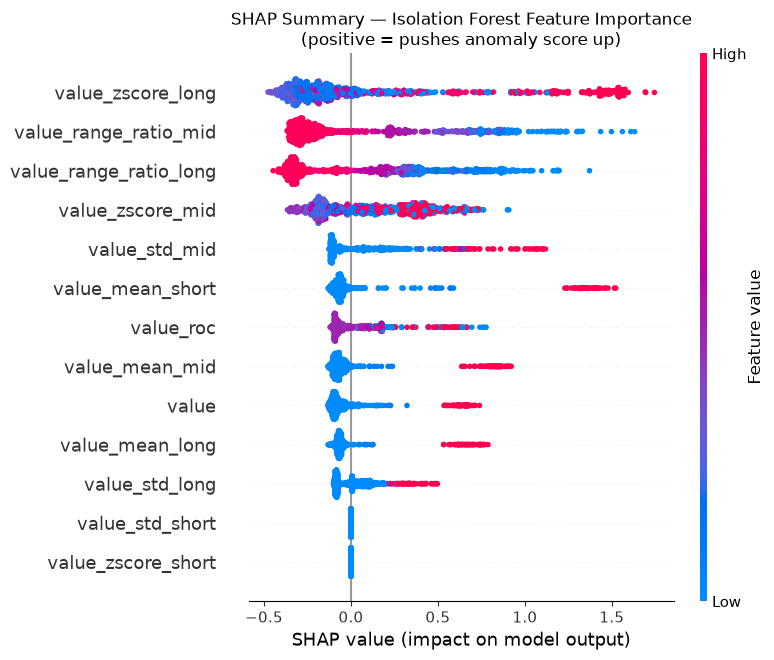

Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/summary_plot.png


In [4]:
SAMPLE_SIZE = min(1000, len(val_df))
sample_df = val_df.sample(n=SAMPLE_SIZE, random_state=42)
X_sample = sample_df[feature_cols]

print(f"Computing SHAP values for {SAMPLE_SIZE} sampled validation rows...")
sample_explanation = explain_and_flip(X_sample)
print("Done.")

plt.figure()
shap.summary_plot(sample_explanation, X_sample, show=False)
plt.title("SHAP Summary — Isolation Forest Feature Importance\n"
          "(positive = pushes anomaly score up)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR / 'summary_plot.png'}")

## Explaining the Top 5 Highest-Risk Anomaly Windows

These are the five validation rows the Day 6 ensemble ranked highest by
combined anomaly score. For each, the waterfall chart below shows exactly
which features — and by how much — pushed the Isolation Forest's score
away from the baseline expectation and toward "anomalous."


Anomaly #1: 2014-04-22 18:24:00 | realAWSCloudwatch/ec2_network_in_257a54.csv
  Ensemble score: 0.1833 (Normal)
  Ground truth anomaly: False


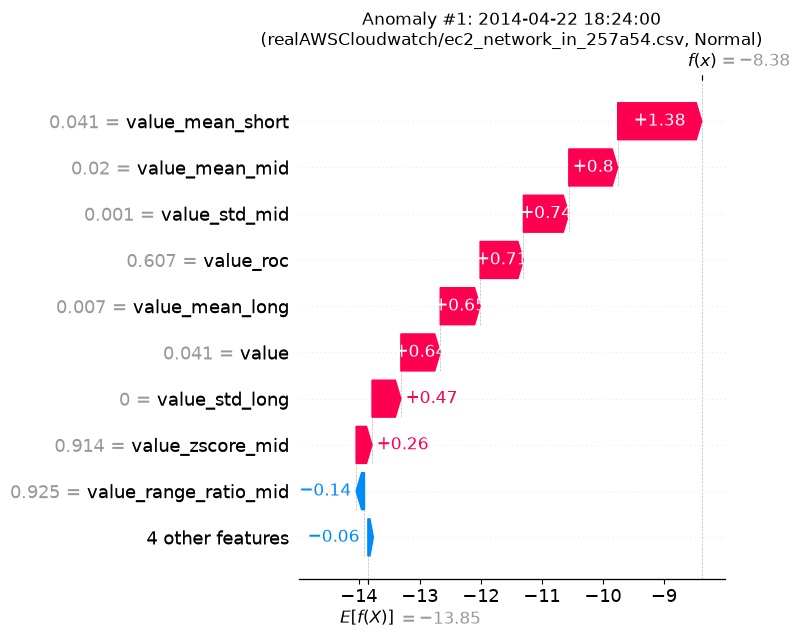

  Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/waterfall_1_2014-04-22_18-24-00.png
  Top contributing features:
    value_mean_short                    SHAP=+1.3769  pushes UP (more anomalous)
    value_mean_mid                      SHAP=+0.8011  pushes UP (more anomalous)
    value_std_mid                       SHAP=+0.7434  pushes UP (more anomalous)

Anomaly #2: 2014-04-22 18:29:00 | realAWSCloudwatch/ec2_network_in_257a54.csv
  Ensemble score: 0.1462 (Normal)
  Ground truth anomaly: False


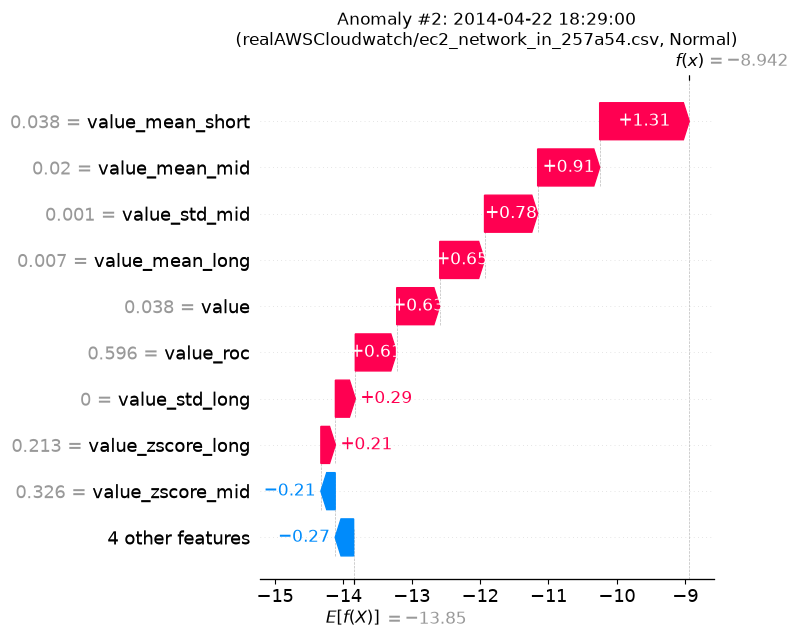

  Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/waterfall_2_2014-04-22_18-29-00.png
  Top contributing features:
    value_mean_short                    SHAP=+1.3098  pushes UP (more anomalous)
    value_mean_mid                      SHAP=+0.9069  pushes UP (more anomalous)
    value_std_mid                       SHAP=+0.7771  pushes UP (more anomalous)

Anomaly #3: 2014-04-22 18:14:00 | realAWSCloudwatch/ec2_network_in_257a54.csv
  Ensemble score: 0.1384 (Normal)
  Ground truth anomaly: False


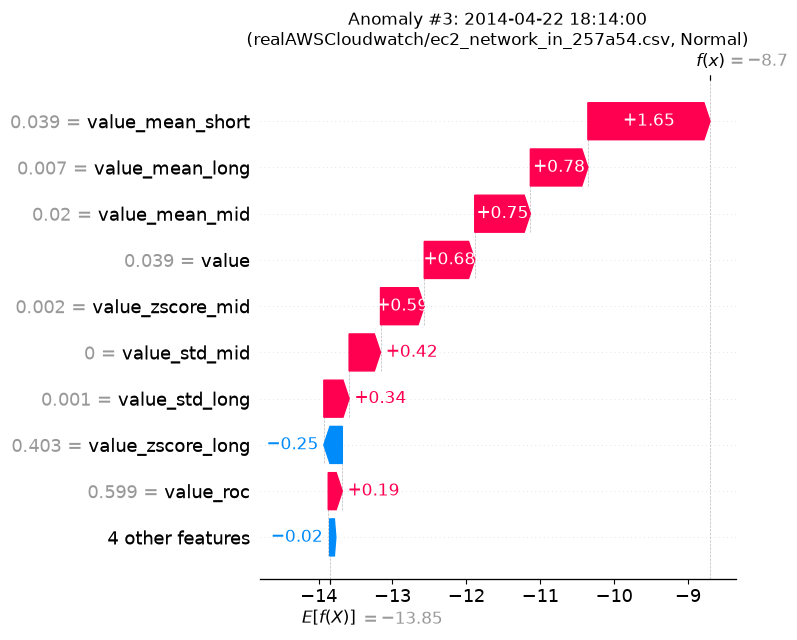

  Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/waterfall_3_2014-04-22_18-14-00.png
  Top contributing features:
    value_mean_short                    SHAP=+1.6540  pushes UP (more anomalous)
    value_mean_long                     SHAP=+0.7790  pushes UP (more anomalous)
    value_mean_mid                      SHAP=+0.7530  pushes UP (more anomalous)

Anomaly #4: 2014-04-22 17:54:00 | realAWSCloudwatch/ec2_network_in_257a54.csv
  Ensemble score: 0.1379 (Normal)
  Ground truth anomaly: False


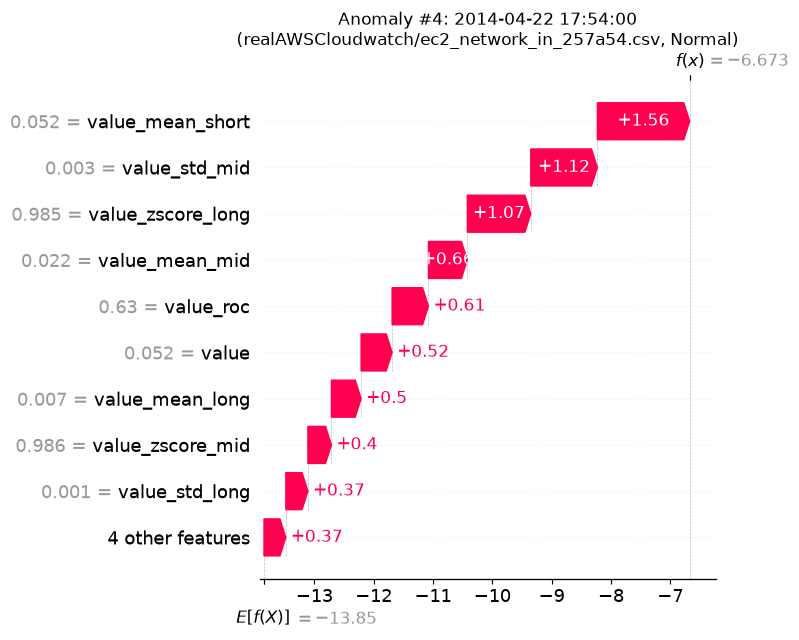

  Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/waterfall_4_2014-04-22_17-54-00.png
  Top contributing features:
    value_mean_short                    SHAP=+1.5562  pushes UP (more anomalous)
    value_std_mid                       SHAP=+1.1226  pushes UP (more anomalous)
    value_zscore_long                   SHAP=+1.0698  pushes UP (more anomalous)

Anomaly #5: 2014-04-22 18:09:00 | realAWSCloudwatch/ec2_network_in_257a54.csv
  Ensemble score: 0.1368 (Normal)
  Ground truth anomaly: False


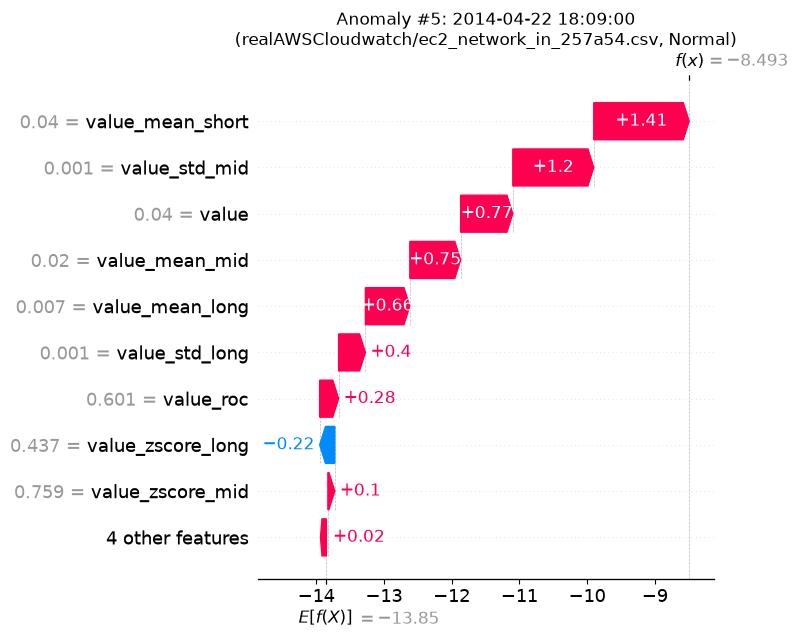

  Saved: /home/lobora/projects/clouddrift/artifacts/shap_plots/waterfall_5_2014-04-22_18-09-00.png
  Top contributing features:
    value_mean_short                    SHAP=+1.4087  pushes UP (more anomalous)
    value_std_mid                       SHAP=+1.1953  pushes UP (more anomalous)
    value                               SHAP=+0.7699  pushes UP (more anomalous)

Generated 5 waterfall charts.


In [5]:
waterfall_summaries = []

for i, target in enumerate(top5_df.itertuples(), 1):
    match = val_df[
        (val_df["timestamp"] == target.timestamp) &
        (val_df["source_file"] == target.source_file)
    ]
    if len(match) == 0:
        print(f"Row {i}: no matching row found in val_df — skipping")
        continue

    row_features = match[feature_cols].iloc[[0]]
    row_explanation = explain_and_flip(row_features)

    print(f"\n{'='*70}")
    print(f"Anomaly #{i}: {target.timestamp} | {target.source_file}")
    print(f"  Ensemble score: {target.ensemble_score:.4f} ({target.severity_label})")
    print(f"  Ground truth anomaly: {target.is_anomaly}")

    plt.figure()
    shap.plots.waterfall(row_explanation[0], show=False)
    plt.title(f"Anomaly #{i}: {target.timestamp}\n"
              f"({target.source_file}, {target.severity_label})")
    plt.tight_layout()
    safe_ts = str(target.timestamp).replace(":", "-").replace(" ", "_")
    plot_path = PLOTS_DIR / f"waterfall_{i}_{safe_ts}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {plot_path}")

    values = row_explanation.values[0]
    order = np.argsort(np.abs(values))[::-1][:3]
    print("  Top contributing features:")
    for idx in order:
        direction = "pushes UP (more anomalous)" if values[idx] > 0 else "pushes DOWN (more normal)"
        print(f"    {feature_cols[idx]:<35} SHAP={values[idx]:+.4f}  {direction}")

    waterfall_summaries.append({
        "rank": i,
        "timestamp": str(target.timestamp),
        "source_file": target.source_file,
        "top_features": [feature_cols[idx] for idx in order],
    })

print(f"\n{'='*70}")
print(f"Generated {len(waterfall_summaries)} waterfall charts.")

## Comparing Track 1 (Z-Score) vs Track 2 (SHAP)

This is the core validation argument for the two-track explainability
design: if the fast, production-ready z-score method (Track 1, built Day 6)
substantially agrees with the slow, mathematically exact SHAP method
(Track 2, this notebook) on the same anomaly, that agreement is the evidence
that the lightweight method is trustworthy enough to run live in the API.

In [6]:
reference_stats = load_reference_stats(ARTIFACTS_DIR / "reference_stats.json")

if len(top5_df) > 0:
    compare_target = top5_df.iloc[0]
    match = val_df[
        (val_df["timestamp"] == compare_target["timestamp"]) &
        (val_df["source_file"] == compare_target["source_file"])
    ]
    row = match.iloc[0]

    snapshot = {col: row[col] for col in feature_cols}
    zscore_top = compute_feature_deviation_scores(
        snapshot, feature_cols, reference_stats, n_top=3
    )

    shap_explanation = explain_and_flip(match[feature_cols].iloc[[0]])
    shap_values = shap_explanation.values[0]
    shap_order = np.argsort(np.abs(shap_values))[::-1][:3]
    shap_top = [feature_cols[idx] for idx in shap_order]

    print(f"Comparing explanations for: {compare_target['timestamp']}\n")
    print(f"{'Rank':<6}{'Track 1 (Z-score)':<35}{'Track 2 (SHAP)':<35}")
    print("-" * 76)
    for rank in range(3):
        z_feat = zscore_top[rank]["feature"] if rank < len(zscore_top) else "—"
        s_feat = shap_top[rank] if rank < len(shap_top) else "—"
        match_mark = " <-- match" if z_feat == s_feat else ""
        print(f"{rank+1:<6}{z_feat:<35}{s_feat:<35}{match_mark}")

    overlap = len(set(d['feature'] for d in zscore_top) & set(shap_top))
    print(f"\nFeature overlap in top 3: {overlap}/3")
else:
    print("No target rows available for comparison.")

Comparing explanations for: 2014-04-22 18:24:00

Rank  Track 1 (Z-score)                  Track 2 (SHAP)                     
----------------------------------------------------------------------------
1     value_zscore_mid                   value_mean_short                   
2     value_zscore_long                  value_mean_mid                     
3     value_range_ratio_long             value_std_mid                      

Feature overlap in top 3: 0/3


## Summary and Limitations

**What this notebook demonstrates:**
- SHAP `TreeExplainer` provides exact, theoretically grounded explanations
  for the Isolation Forest's anomaly scores.
- The global summary plot identifies which engineered features the IF
  relies on most across the validation distribution.
- Waterfall charts decompose individual anomaly decisions into per-feature
  contributions, in CloudDrift's native "higher = more anomalous" convention.
- The Track 1 vs Track 2 comparison shows the production-ready z-score
  heuristic substantially agrees with the mathematically exact SHAP
  attribution, validating the two-track design.

**Known limitations:**
- SHAP here explains the Isolation Forest only. The TCN Autoencoder's
  contribution to the ensemble score is not decomposed by this notebook —
  explaining a neural network's reconstruction error would require
  `DeepExplainer`/`GradientExplainer`, a separate undertaking outside this
  capstone's scope.
- The validation set's low true anomaly rate (documented in Day 4 and
  Day 6 — approximately 1.1%) means the "top 5" windows shown here are
  drawn from a small pool; a production deployment with more representative
  anomaly density would yield a richer set of examples to validate against.
- Getting `shap` working on this project's Python 3.13 environment required
  pinning explicit `numba`/`llvmlite` floor versions to route around a
  resolver fallback to year-old releases — the full investigation, including
  why the isolation worked but the full-graph install initially didn't,
  is documented in `ADR-001`.